In [13]:
import numpy as np
import ase
import ase.io
import matplotlib.pyplot as plt
from potentials import gb, vec_gb
from scipy.optimize import curve_fit

In [2]:
frames = ase.io.read("xyz_files/ellipsoids_with_axes.xyz", ":")
duped_frames = ase.io.read("xyz_files/duped_ellipsoids_with_axes.xyz", ":")
two_frames = ase.io.read("xyz_files/two_ells_with_axes.xyz", ":")

In [3]:
frames[0].arrays

{'numbers': array([0, 0]),
 'positions': array([[-0.        , -0.        ,  3.27355258],
        [ 2.86203436,  4.88789961,  6.73143792]]),
 'c_q': array([[ 0.15965019,  0.67170996, -0.07507814,  0.71950039],
        [-0.213207  , -0.03290243,  0.26500539,  0.93980442]]),
 'axes': array([[2.5, 2.5, 1. ],
        [2.5, 2.5, 1. ]]),
 'or_vec': array([[ 0.94261869, -0.32251475,  0.086338  ],
        [-0.17484571,  0.48407642,  0.85737915]])}

In [4]:
uhat1_array = []
uhat2_array = []
r_array = []
input_matrices = []
ydata = []
for frame in two_frames:
    uhat1_array.append(frame.arrays["or_vec"][0])
    uhat2_array.append(frame.arrays["or_vec"][1])
    r_array.append(frame.get_distance(0, 1, mic=True, vector=True))
    matrix = np.array([frame.arrays["or_vec"][0], frame.arrays["or_vec"][1], r_array[-1]])
    assert np.shape(matrix) == (3, 3)
    input_matrices.append(matrix)
    ydata.append(frame.info["intermolecular_energy_pa"] * 24)

In [5]:
print(np.shape(input_matrices))

(4168, 3, 3)


In [6]:
def gb_wrapper(matrix, sigma0, eps0, kappa, kappa_prime, mu, nu):
    uhat1 = matrix[:, 0]
    uhat2 = matrix[:, 1]
    r = matrix[:, 2]
    return vec_gb(uhat1, uhat2, r, sigma0, eps0, kappa, kappa_prime, mu, nu)

In [7]:
p0 = [5.3, 0.8, 0.5, 0.2, 2., 1.]
lower_bounds = [0, 0, 0.3, 0.1, -np.inf, -np.inf]
upper_bounds = [10., np.inf, 0.9, 1., np.inf, np.inf]
bounds = (lower_bounds, upper_bounds)

In [8]:
small_p0 = p0 = [5.3, 0.8, 0.5, 0.2]
small_lower_bounds = [0, 0, 0.3, 0.1]
small_upper_bounds = [10., np.inf, 0.9, 1.]
small_bounds = (small_lower_bounds, small_upper_bounds)

def small_gb_wrapper(matrix, sigma0, eps0, kappa, kappa_prime):
    return gb_wrapper(matrix, sigma0, eps0, kappa, kappa_prime, 2, 1)

In [11]:
popt, pcov = curve_fit(
    small_gb_wrapper,
    input_matrices,
    ydata,
    p0=small_p0,
    bounds=small_bounds,
    maxfev=50_000,
    loss="soft_l1",
    f_scale=0.1
)

In [12]:
popt

array([5.69087343, 0.61536223, 0.51058821, 0.90649885])

In [14]:
# face-to-face energy curve
u1 = np.array([0, 0, 1])
u2 = np.array([0, 0, 1])

distances = np.linspace(3.0, 10.0, 100)
energies = []

for d in distances:
    r = np.array([0, 0, d])
    e = gb(u1, u2, r, popt[0], popt[1], popt[2], popt[3], 2, 1)
    energies.append(e)

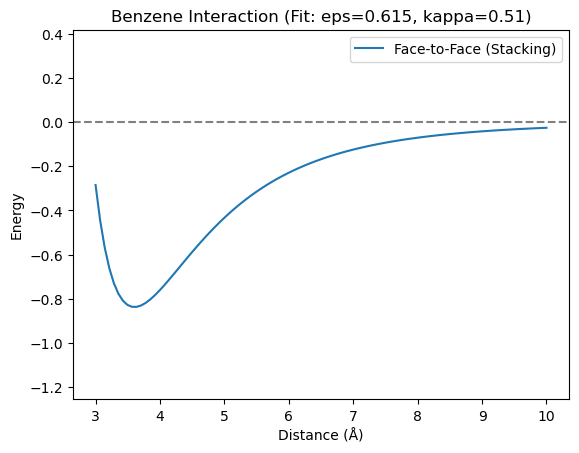

In [15]:
plt.plot(distances, energies, label='Face-to-Face (Stacking)')
plt.axhline(0, color='gray', linestyle='--')
plt.ylim(min(energies)*1.5, abs(min(energies))*0.5)
plt.xlabel('Distance (Å)')
plt.ylabel('Energy')
plt.title(f'Benzene Interaction (Fit: eps={popt[1]:.3f}, kappa={popt[2]:.2f})')
plt.legend()
plt.show()

In [16]:
min_energy = min(energies)
print(f"Maximum Attraction Depth: {min_energy:.4f}")

Maximum Attraction Depth: -0.8372


In [19]:
opt_sigma0 = popt[0]
opt_kappa = popt[2]
fixed_mu = 2.
fixed_nu = 1.

def energy_fit_wrapper(matrices, eps0, kappa_prime):
    return gb_wrapper(matrices, opt_sigma0, eps0, opt_kappa, kappa_prime, fixed_mu, fixed_nu)

p0_e = [popt[1], popt[3]]
bounds_e = ([0., 0.], [np.inf, np.inf])

In [20]:
popt_e, pcov_e = curve_fit(
    energy_fit_wrapper,
    input_matrices,
    ydata,
    p0=p0_e,
    bounds=bounds_e,
    maxfev=50_000,
    loss="soft_l1",
    f_scale=0.5
)
print(popt_e)

[0.52746396 0.77302839]


In [21]:
param_fit = [opt_sigma0, popt_e[0], opt_kappa, popt_e[1], fixed_mu, fixed_nu]
print(param_fit)

[np.float64(5.6908734316048575), np.float64(0.5274639566548358), np.float64(0.5105882064300075), np.float64(0.7730283946074973), 2.0, 1.0]


In [25]:
distances = np.linspace(3.0, 9.0, 100)
e_face = []
e_edge = []
for d in distances:
    e_face.append(gb([0, 0, 1], [0, 0, 1], [0, 0, d], *param_fit))
    e_edge.append(gb([0, 0, 1], [0, 0, 1], [d, 0, 0], *param_fit))

<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_20746/4242197226.py:7: SyntaxWarning: invalid escape sequence '\A'
  plt.xlabel('Distance ($\AA$)')


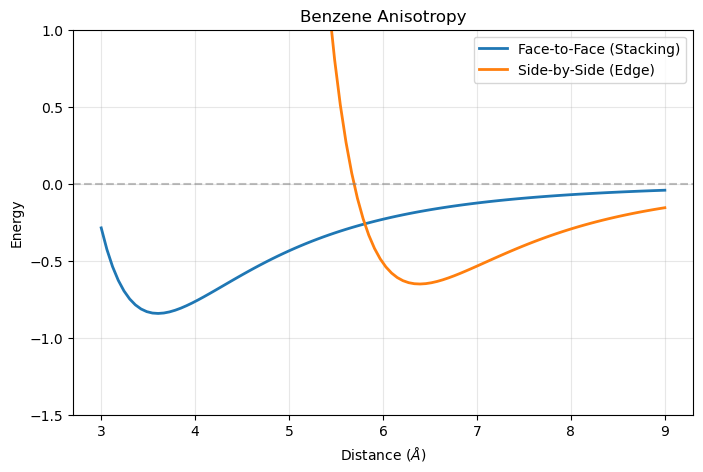

Face Well Depth: -0.8424
Edge Well Depth: -0.6512


In [27]:
plt.figure(figsize=(8, 5))
plt.plot(distances, e_face, label='Face-to-Face (Stacking)', linewidth=2)
plt.plot(distances, e_edge, label='Side-by-Side (Edge)', linewidth=2)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.ylim(-1.5, 1.0) # Adjust based on your depth
plt.xlabel('Distance ($\AA$)')
plt.ylabel('Energy')
plt.title(f'Benzene Anisotropy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Face Well Depth: {min(e_face):.4f}")
print(f"Edge Well Depth: {min(e_edge):.4f}")